Module to run the diffusion model (using Wavestitch)

In [1]:
"""import cell"""

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
from torch import device
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append("..")

import autoencoder as ae
from data_utils import Preprocessor
from training_utils import fetchModel
from utils import DimensionalityEstimator, Losses, get_frechet_distance

import fouad_wavestitch.training_and_saving_models as model_trainer

"""get diffusion config params + set dataset"""
from fouad_wavestitch.param_extractor import dataset_name, ae_args, diffusion_args, LDM_args


Using device: cuda
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%


In [2]:
"""OLD Wavestitch"""

# np.random.seed(42)
# torch.manual_seed(42)
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset', '-d', type=str,
#                     help='MetroTraffic, BeijingAirQuality, AustraliaTourism, RossmanSales, PanamaEnergy', required=True)
# parser.add_argument('-backbone', type=str, help='Transformer, Bilinear, Linear, S4', default='S4')
# parser.add_argument('-beta_0', type=float, default=0.0001, help='initial variance schedule')
# parser.add_argument('-beta_T', type=float, default=0.02, help='last variance schedule')
# parser.add_argument('-timesteps', '-T', type=int, default=200, help='training/inference timesteps')
# parser.add_argument('-hdim', type=int, default=64, help='hidden embedding dimension')
# parser.add_argument('-lr', type=float, default=1e-4, help='learning rate')
# parser.add_argument('-batch_size', type=int, help='batch size', default=1024)
# parser.add_argument('-epochs', type=int, default=1000, help='training epochs')
# parser.add_argument('-layers', type=int, default=4, help='number of hidden layers')
# parser.add_argument('-window_size', type=int, default=32, help='the size of the training windows')
# parser.add_argument('-stride', type=int, default=1, help='the stride length to shift the training window by')
# parser.add_argument('-num_res_layers', type=int, default=4, help='the number of residual layers')
# parser.add_argument('-res_channels', type=int, default=64, help='the number of res channels')
# parser.add_argument('-skip_channels', type=int, default=64, help='the number of skip channels')
# parser.add_argument('-diff_step_embed_in', type=int, default=32, help='input embedding size diffusion')
# parser.add_argument('-diff_step_embed_mid', type=int, default=64, help='middle embedding size diffusion')
# parser.add_argument('-diff_step_embed_out', type=int, default=64, help='output embedding size diffusion')
# parser.add_argument('-s4_lmax', type=int, default=100)
# parser.add_argument('-s4_dstate', type=int, default=64)
# parser.add_argument('-s4_dropout', type=float, default=0.0)
# parser.add_argument('-s4_bidirectional', type=bool, default=True)
# parser.add_argument('-s4_layernorm', type=bool, default=True)
# parser.add_argument('-propCycEnc', type=bool, default=False)
# args = parser.parse_args()
# dataset = args.dataset
# device = device('cuda' if torch.cuda.is_available() else 'cpu')
# preprocessor = Preprocessor(dataset, args.propCycEnc)
# df = preprocessor.df_cleaned
# training_df = df.loc[preprocessor.train_indices]
# test_df = df.loc[preprocessor.test_indices]
# hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)
# # training_samples = []
# d_vals_tensor = from_numpy(training_df.values)
# training_samples = d_vals_tensor.unfold(0, args.window_size, 1).transpose(1, 2)
# # masks = m_vals_tensor.unfold(0, args.window_size, 1)
# # for i in range(0, len(training_df) - args.window_size + 1, args.stride):
# #     window = training_df.iloc[i:i + args.window_size].values
# #     training_samples.append(window)
# in_dim = len(training_df.columns)
# out_dim = len(training_df.columns) - len(hierarchical_column_indices)
# training_dataset = MyDataset(training_samples.float())
# model = fetchModel(in_dim, out_dim, args).to(device)
# diffusion_config = fetchDiffusionConfig(args)
# optimizer = optim.Adam(model.parameters(), lr=args.lr)
# criterion = nn.MSELoss()
# dataloader = DataLoader(training_dataset, batch_size=args.batch_size, shuffle=True)
# all_indices = np.arange(len(training_df.columns))

# # Find the indices not in the index_list
# remaining_indices = np.setdiff1d(all_indices, hierarchical_column_indices)

# # Convert to an ndarray
# non_hier_cols = np.array(remaining_indices)
# """TRAINING"""
# for epoch in range(args.epochs):
#     total_loss = 0.0
#     for batch in dataloader:
#         batch = batch.to(device)
#         timesteps = randint(diffusion_config['T'], size=(batch.shape[0],)).to(device)
#         sigmas = normal(0, 1, size=batch.shape).to(device)
#         """Forward noising"""
#         alpha_bars = diffusion_config['alpha_bars'].to(device)
#         coeff_1 = sqrt(alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         coeff_2 = sqrt(1 - alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         conditional_mask = np.ones(batch.shape)
#         conditional_mask[:, :, non_hier_cols] = 0
#         conditional_mask = from_numpy(conditional_mask).float().to(device)
#         batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
#         batch_noised = batch_noised.to(device)
#         timesteps = timesteps.reshape((-1, 1))
#         # timesteps = timesteps.to(device)
#         sigmas_predicted = model(batch_noised, timesteps)
#         optimizer.zero_grad()
#         sigmas_permuted = sigmas[:, :, non_hier_cols].permute((0, 2, 1))
#         sigmas_permuted = sigmas_permuted.to(device)
#         loss = criterion(sigmas_predicted, sigmas_permuted)
#         loss.backward()
#         total_loss += loss
#         optimizer.step()
#     print(f'epoch: {epoch}, loss: {total_loss}')
# path = f'saved_models/{args.dataset}/'
# if args.propCycEnc:
#     filename = "model_prop.pth"
# else:
#     filename = "model.pth"
# filepath = os.path.join(path, filename)

# if not os.path.exists(path):
#     os.makedirs(path)
# torch.save(model.state_dict(), filepath)


'OLD Wavestitch'

In [3]:
"""Data preprocessing (from training_wavestitch.py)"""

np.random.seed(diffusion_args.random_seed)
torch.manual_seed(diffusion_args.random_seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preprocessing (scales all data except for encoded features, then train-test splits it)
preprocessor= Preprocessor(dataset_name, diffusion_args.propCycEnc)
df          = preprocessor.df_cleaned
n_dim       = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Dataset dimensionality: {n_dim:.2f}")

training_df = df.loc[preprocessor.train_indices]
test_df     = df.loc[preprocessor.test_indices]
hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

X_tensor_train = torch.tensor(training_df.values, dtype=torch.float32)
train_dataset  = TensorDataset(X_tensor_train, X_tensor_train)
X_tensor_test  = torch.tensor(test_df.values, dtype=torch.float32)
test_dataset   = TensorDataset(X_tensor_test, X_tensor_test)


Dataset dimensionality: 4.01


In [4]:
"""Autoencoder training. Saves the model so no need to run this cell everytime"""

filepath, input_size = model_trainer.train_and_save_autoencoder(train_dataset, test_dataset, ae_args, dataset_name, device)
autoencoder = ae.Autoencoder(input_size, ae_args.ae_layer1_dim, ae_args.ae_layer2_dim, ae_args.ae_latent_dim, ae_args.ae_dropout_prob)
autoencoder.load_state_dict(torch.load(filepath))
autoencoder.to(device)
autoencoder.eval();


Epoch [20/150], training loss: 0.3158
Validation loss: 0.4914
Epoch [40/150], training loss: 0.2960
Validation loss: 0.4994
Epoch [60/150], training loss: 0.2766
Validation loss: 0.4945
Epoch [80/150], training loss: 0.2674
Validation loss: 0.5075
Early stopping triggered


input_mean tensor(-0.0731)
recons mean tensor(0.0624)
MAE tensor(0.5976)


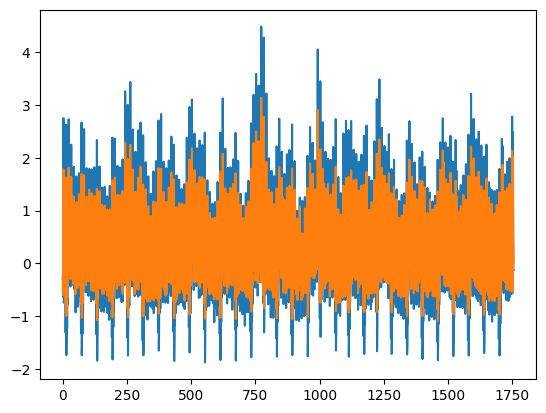

In [5]:
"""[sanity check] Apply AE latent-delatent to TEST dataset"""

loader = DataLoader(test_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input     = batch[0].to(device)
        latent_batch= autoencoder.encode_to_latent(x_input)
        x_output    = autoencoder.decode_from_latent(latent_batch)
        latents.append(latent_batch.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print("input_mean", torch.mean(X_input))
print("recons mean", torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print("MAE", MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


In [6]:
"""Training wavestitch diffusion on TRAIN set (from training_wavestitch.py)"""

# changed S4model.py > SSKernelNPLR.register to load the model
filepath, total_loss, in_dim, out_dim = model_trainer.train_and_save_diffusion(training_df, hierarchical_column_indices, diffusion_args, dataset_name, device)

# Load model
model      = fetchModel(in_dim, out_dim, diffusion_args)
state_dict = torch.load(filepath)
state_dict = {k: v.clone() for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(device)
model.eval();


epoch: 10/300, total loss: 5.52814793586731
epoch: 20/300, total loss: 3.3993064165115356
epoch: 30/300, total loss: 2.113934814929962
epoch: 40/300, total loss: 1.739492118358612
epoch: 50/300, total loss: 1.5900573432445526
epoch: 60/300, total loss: 1.4690656810998917
epoch: 70/300, total loss: 1.468227282166481
epoch: 80/300, total loss: 1.4014084786176682
epoch: 90/300, total loss: 1.3907809853553772
epoch: 100/300, total loss: 1.3576803803443909
epoch: 110/300, total loss: 1.3201693445444107
epoch: 120/300, total loss: 1.3471590727567673
epoch: 130/300, total loss: 1.2921582162380219
epoch: 140/300, total loss: 1.2541300058364868
epoch: 150/300, total loss: 1.2690460830926895
epoch: 160/300, total loss: 1.2438079565763474
epoch: 170/300, total loss: 1.2235974669456482
epoch: 180/300, total loss: 1.2083934843540192
epoch: 190/300, total loss: 1.2211609780788422
epoch: 200/300, total loss: 1.2056673914194107
epoch: 210/300, total loss: 1.2016107887029648
epoch: 220/300, total loss:

In [7]:
# # Synthesize samples using terminal version
# !python wavestitch_synthesizer.py -dataset RossmanSales -synth_mask C


In [8]:
"""Synthesize samples on TEST set [from wavestitch_synthesizer.py]"""

synth = model_trainer.Synthesizer(df, preprocessor, diffusion_args, dataset_name)
synth_df_out, exec_times = synth.synthesize(n_trials=diffusion_args.n_trials)

with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_cycStd.txt', 'a') as f:
    arr_time = np.array(exec_times)
    f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


File 1/1 done


In [9]:
# """Synthesize samples on TEST set [from wavestitch_synthesizer.py]"""

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # --- Helper ---
# def decimal_places(series):
#     return series.apply(lambda x: len(str(x).split('.')[1]) if '.' in str(x) else 0).max()

# def create_pipelined_noise(batch_shape, device, window_size, stride):
#     # avoid passing test_batch directly for noise creation
#     total_rows = stride * (batch_shape[0]-1) + window_size
#     sampled    = torch.normal(0, 1, (total_rows, batch_shape[2])).to(device)
#     return sampled.unfold(0, window_size, stride).transpose(1, 2)

# # --- Load Data ---
# np.random.seed(diffusion_args.random_seed)
# torch.manual_seed(diffusion_args.random_seed)

# end_indices       = preprocessor.test_indices[-1]
# start_indices     = preprocessor.test_indices[0]
# window_count      = ((end_indices + 1 - diffusion_args.window_size - start_indices) // diffusion_args.stride) + 1
# tilde_start       = end_indices + 1 - diffusion_args.window_size - (window_count * diffusion_args.stride)
# additional_indices= start_indices - tilde_start
# # tweaking test_df to add more context to it
# test_df           = df.loc[preprocessor.train_indices[-additional_indices:] + preprocessor.test_indices]
# test_df_with_hierarchy = preprocessor.cyclicDecode(test_df)
# decimal_accuracy  = {k: decimal_places(preprocessor.df_orig[k])
#                      for k in test_df_with_hierarchy.columns}
# metadata          = test_df_with_hierarchy[preprocessor.hierarchical_features_uncyclic]
# rows_to_synth     = metadataMask(metadata, diffusion_args.synth_mask, dataset_name)
# real_df           = test_df_with_hierarchy[rows_to_synth]
# df_synth          = test_df.copy()

# # --- Model Prep ---
# data_tensor = from_numpy(df_synth.values)
# mask_tensor = from_numpy(rows_to_synth.values)
# windows     = data_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride).transpose(1, 2)
# masks       = mask_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride)
# hierarchical_column_indices = df_synth.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

# non_hier_cols   = np.setdiff1d(np.arange(len(df_synth.columns)), hierarchical_column_indices)
# test_dataset    = MyDataset(windows.float())
# mask_dataset    = MyDataset(masks)
# model           = fetchModel(len(df_synth.columns), len(non_hier_cols), diffusion_args).to(device)
# diffusion_config= fetchDiffusionConfig(diffusion_args)
# test_loader     = DataLoader(test_dataset, batch_size=diffusion_args.diff_batch_size)
# mask_loader     = DataLoader(mask_dataset, batch_size=diffusion_args.diff_batch_size)
# model_path      = f'saved_models/{dataset_name}/model_prop.pth' if diffusion_args.propCycEnc else f'saved_models/{dataset_name}/model.pth'
# saved_params    = torch.load(model_path, map_location=device)

# model.load_state_dict(saved_params)
# for param in model.parameters():
#     param.requires_grad = False
# model.eval()

# real_df_out = preprocessor.rescale(real_df).reset_index(drop=True).round(decimal_accuracy)
# path        = f'generated/{dataset_name}/{diffusion_args.synth_mask}/'
# os.makedirs(path, exist_ok=True)
# real_path   = os.path.join(path, 'real.csv')
# if not os.path.exists(real_path):
#     real_df_out.to_csv(real_path)

# # --- Inference ---
# @torch.no_grad()
# def synthesize_samples(input_dataset, n_trials, device, test_loader, mask_loader, stride, window_size, hierarchical_column_indices, 
#                        diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, propCycEnc, path):
#     """Wavestitch conditional synthesis, and writes to csv file for eacn trial
#     - synth_df_out: is SCALED back using the original scaling of df"""
#     num_ops    = 0
#     exec_times = []
#     for trial in range(n_trials):
#         start_time   = timer()
#         synth_tensor = torch.empty(0, input_dataset.inputs.shape[2]).to(device)
#         for idx, (test_batch, mask_batch) in enumerate(zip(test_loader, mask_loader)):
#             test_batch = test_batch.to(device)
#             mask_batch = mask_batch.to(device)
#             noise = create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#             x    = noise.clone()
#             x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
#             # for step in range(diffusion_config['T'] - 1, -1, -1):
#             for step in reversed(range(diffusion_config['T'])):
#                 times = torch.full((test_batch.shape[0], 1), step).to(device)
#                 ab_t  = diffusion_config['alpha_bars'][step].to(device)
#                 ab_t1 = diffusion_config['alpha_bars'][step - 1].to(device) if step > 0 else None
#                 at    = diffusion_config['alphas'][step].to(device)
#                 b_t   = diffusion_config['betas'][step].to(device)
#                 sampled_noise= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#                 cached       = torch.sqrt(ab_t) * test_batch + torch.sqrt(1 - ab_t) * sampled_noise
#                 mask_expanded= torch.zeros_like(test_batch, dtype=bool)
#                 for c in non_hier_cols:
#                     mask_expanded[:, :, c] = mask_batch
#                 x[~mask_expanded] = cached[~mask_expanded]
#                 x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
#                 eps = model(x, times)
#                 eps = eps.permute(0, 2, 1)
#                 variance = 0.0
#                 if step > 0:
#                     variance = b_t * ((1 - ab_t1) / (1 - ab_t)) * torch.normal(0, 1, size=eps.shape).to(device)
#                 norm_denoised= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
#                 norm_denoised[:, :, non_hier_cols] = (x[:, :, non_hier_cols] - ((b_t / torch.sqrt(1 - ab_t)) * eps)) / torch.sqrt(at)
#                 norm_denoised[:, :, non_hier_cols] += variance
#                 x[mask_expanded]  = norm_denoised[mask_expanded]
#                 x[~mask_expanded] = test_batch[~mask_expanded]
#                 # we use 1: in line below and not 0: because 0 has no predecessor window to copy from
#                 x[1:, : (window_size - stride), :] = x.roll(1, 0)[1:, stride: window_size, :]
#                 if trial == 0:
#                     num_ops += 1
#             if idx == 0:
#                 generated = torch.cat((x[0], x[1:, (window_size - stride):, :].reshape(-1, x.shape[2])), dim=0)
#             else:
#                 generated = x[:, (window_size - stride):, :].reshape(-1, x.shape[2])
#             synth_tensor  = torch.cat((synth_tensor, generated), dim=0)

#         exec_times.append(timer() - start_time)
#         df_synthesized = pd.DataFrame(synth_tensor.cpu().numpy(), columns=df.columns)
#         # synth_df_out   = preprocessor.decode(df_synthesized, rescale=True)[rows_to_synth.reset_index(drop=True)].round(decimal_accuracy)
#         mask         = rows_to_synth.to_numpy() if hasattr(rows_to_synth, "to_numpy") else np.array(rows_to_synth)
#         # un-scale
#         synth_df_out = preprocessor.decode(df_synthesized, rescale=True)[mask].round(decimal_accuracy)
#         file_suffix  = 'cycProp' if propCycEnc else 'cycStd'
#         synth_df_out.to_csv(f'{path}synth_hyacinth_pipeline_stride_{stride}_trial_{trial}_{file_suffix}.csv')
#         print(f"File {trial+1}/{n_trials} done")
#         if trial == 0:
#             with open(f'{path}denoiser_calls_pipeline_stride_{stride}_{file_suffix}.txt', 'w') as f:
#                 f.write(str(num_ops))
#     return synth_df_out, exec_times

# synth_df_out, exec_times= synthesize_samples(test_dataset, diffusion_args.n_trials, device, test_loader, mask_loader, diffusion_args.stride, diffusion_args.window_size, hierarchical_column_indices, 
#                                              diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, diffusion_args.propCycEnc, path)

# with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_cycStd.txt', 'a') as f:
#     arr_time = np.array(exec_times)
#     f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


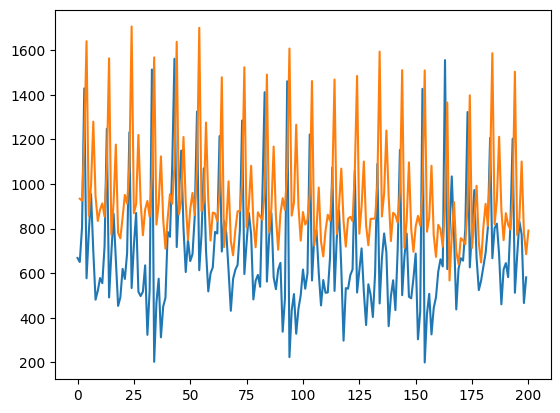

In [10]:
df2 = preprocessor.decode(df, rescale=True)

plt.plot(df2.iloc[:200, 1])
plt.plot(synth_df_out.iloc[:200, 1])


In [11]:
print(synth_df_out.mean())
# n_trial = 5
# Sales        8111.763802
# Customers     951.133751

# n_trial = 2
# Sales        7689.264087
# Customers     892.767217

# n_trial = 1
# Sales        7599.594764
# Customers     885.080250


Sales        7760.333523
Customers     892.223677
Year         2015.000000
Month           4.019351
Day            15.997723
Store           5.501992
dtype: float64


In [ ]:
"""LDM"""
# NOTE: SSSDS4_diffusion.py > SSSDS4Imputer class > forward() has an issue with permuting tuples
# TODO: there is a .permute(0, 2, 1) in forward(), which forces us to use .permute() everywhere we call the function

ldm_trainer = model_trainer.LDMTrainer(autoencoder, LDM_args, dataset_name, device)

# 2. Train and Save the model
filepath, total_train_loss, total_test_loss, in_dim, out_dim, latent_dim = ldm_trainer.train_and_save_model(
    training_df, test_df, hierarchical_column_indices) # hierarchical_column_indices can be None or an actual list if needed

diffusion_config = ldm_trainer.diffusion_config

# 3. Load LDM (directly from the trainer instance or load from saved path)
LDM_model = ldm_trainer.LDM_model
LDM_model.eval()
print("LDM model loaded and ready for use.")

# 4. sampling
z_T = torch.randn((LDM_args.num_samples, latent_dim, 1), device=device)
x   = z_T
LDM_model.eval()
with torch.no_grad():
    for t_step in reversed(range(diffusion_config['T'])):
        t         = torch.full((LDM_args.num_samples, 1), t_step, device=device, dtype=torch.long)        
        eps       = LDM_model(x.permute(0, 2, 1), t)
        alpha_bar = ldm_trainer.diffusion_config['alpha_bars'][t_step].to(device)
        alpha     = ldm_trainer.diffusion_config['alphas'][t_step].to(device)
        beta      = ldm_trainer.diffusion_config['betas'][t_step].to(device)        
        if t_step > 0:
            noise = torch.randn_like(x) # Consistent shape (N, L_dim, 1)
        else:
            noise = 0
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * noise

latent_repr    = x.mean(dim=-1)
latent_repr_np = latent_repr.cpu().numpy()
fitted_scaler  = ldm_trainer.get_latent_scaler()
inverse_scaled_latent_repr_np = fitted_scaler.inverse_transform(latent_repr_np)
decoded_tensor = autoencoder.decode_from_latent(torch.tensor(inverse_scaled_latent_repr_np, dtype=torch.float32).to(device))
decoded_np     = decoded_tensor.detach().cpu().numpy()
generated_df   = pd.DataFrame(decoded_np, columns=training_df.columns)


Scaled Latent samples (training): torch.Size([6063, 4, 1])
Scaled Latent samples (test): torch.Size([1757, 4, 1])
Starting LDM training...
Epoch: 20/150, Avg Epoch Loss: 0.4344
Epoch: 40/150, Avg Epoch Loss: 0.4363
Epoch: 60/150, Avg Epoch Loss: 0.4305
Epoch: 80/150, Avg Epoch Loss: 0.4294
Epoch: 100/150, Avg Epoch Loss: 0.4270
Epoch: 120/150, Avg Epoch Loss: 0.4224
Epoch: 140/150, Avg Epoch Loss: 0.4113
Starting LDM evaluation...
Test Loss: 0.5266
LDM Training complete. Final Training Loss: 0.4410, Final Test Loss: 0.5266
LDM model saved to: saved_models/RossmanSales/latent_model.pth
LDM model loaded and ready for use.


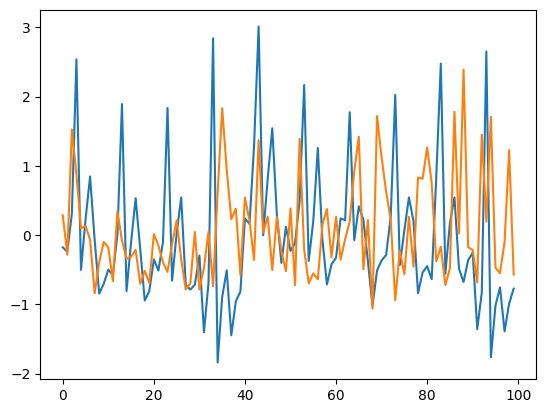

In [13]:
variate_to_plot = 1
plt.plot(df.iloc[:100, variate_to_plot])
plt.plot(generated_df.iloc[:100,variate_to_plot])


tensor(0.0677)
tensor(0.0601)
tensor(0.3798)


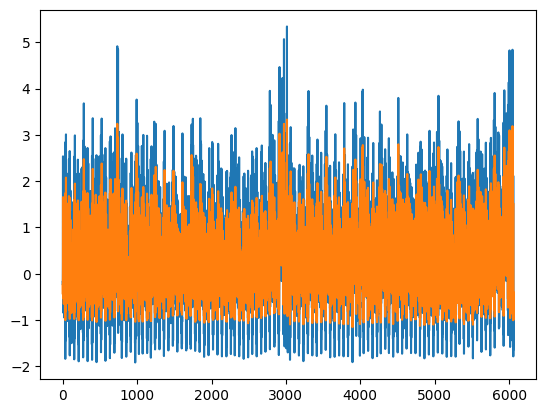

In [14]:
"""[OLD] LDM"""

training_df_tensor = torch.tensor(training_df.values, dtype=torch.float32).to(device)
latent_features  = autoencoder.encode_to_latent(x_input)
# %%%%%%%%%%%%%%%%%%
@torch.no_grad()
def latent_synthesize_samples(input_dataset, n_trials, device, test_loader, model, autoencoder, diffusion_config):
    for trial in range(n_trials):
        synth_latent = torch.empty(0, latent_dim).to(device)
        for test_batch in test_loader:
            test_batch = test_batch.to(device)
            latent_batch = autoencoder.encode_to_latent(test_batch)
            noise = torch.normal(0, 1, latent_batch.shape).to(device)
            x = noise.clone()

            for step in reversed(range(diffusion_config['T'])):
                times = torch.full((latent_batch.shape[0], 1), step).to(device)
                # diffusion update on latent x here
                eps = model(x, times)
                # denoise x according to diffusion equation in latent space

            synth_latent = torch.cat((synth_latent, x), dim=0)

        x_output = autoencoder.decode_from_latent(synth_latent)
        # Save or return x_output as synthesized samples
    return x_output

# %%%%%%%%%%%%%%%%%

x_output= autoencoder.decode_from_latent(latent_features)


# =========================================================
ae_dataset = train_dataset #val_dataset # 
loader     = DataLoader(ae_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print(torch.mean(X_input))
print(torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print(MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


In [16]:
"""Metrics for AE-reconstructed data quality"""

# Prepare data
X_real  = df.values.astype(np.float32)
X_synth = synth_df_out.values.astype(np.float32)

# Split + scale data
X_train, X_val= train_test_split(X_real, test_size=0.2, random_state=42)
scaler        = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)
X_synth_scaled= scaler.transform(X_synth)

# Convert to tensors + build datasets
X_train_tensor = torch.tensor(X_train_scaled)
X_val_tensor   = torch.tensor(X_val_scaled)
X_synth_tensor = torch.tensor(X_synth_scaled, dtype=torch.float32).to(device)
train_dataset  = TensorDataset(X_train_tensor, torch.zeros(len(X_train_tensor)))
val_dataset    = TensorDataset(X_val_tensor, torch.zeros(len(X_val_tensor)))

# Training setup
device      = ae.device
input_size  = X_train_tensor.shape[1] # num of features
train_loader= DataLoader(train_dataset, batch_size=ae_args.ae_batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)
autoencoder = ae.Autoencoder(input_size, ae_args.ae_layer1_dim, ae_args.ae_layer2_dim, ae_args.ae_latent_dim, ae_args.ae_dropout_prob).to(device)
optimizer   = torch.optim.AdamW(autoencoder.parameters(), lr=ae_args.ae_optimizer_lr, weight_decay=ae_args.ae_weight_decay)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, ae_args.ae_scheduler_mode, patience=ae_args.ae_scheduler_patience, factor=ae_args.ae_scheduler_factor)

# Train AE
trainer = ae.TrainAutoencoder()
trainer.train_autoencoder(device, autoencoder, ae_args.ae_training_epochs, train_loader, optimizer, scheduler,
                          validation_loader=val_loader, patience=ae_args.ae_training_patience)

# Make latents + reconstruction (optional)
autoencoder.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    real_latents = autoencoder.encode_to_latent(X_val_tensor).cpu().numpy()
    synth_latents= autoencoder.encode_to_latent(X_synth_tensor).cpu().numpy()
    # X_reconstructed = autoencoder(X_train_tensor.to(device)).cpu().numpy()

#  FID metric
FID_distance = get_frechet_distance(real_latents, synth_latents)
print(real_latents.shape)
print(synth_latents.shape)
print(FID_distance)


ValueError: X has 6 features, but StandardScaler is expecting 10 features as input.

t-SNE done.
UMAP done.


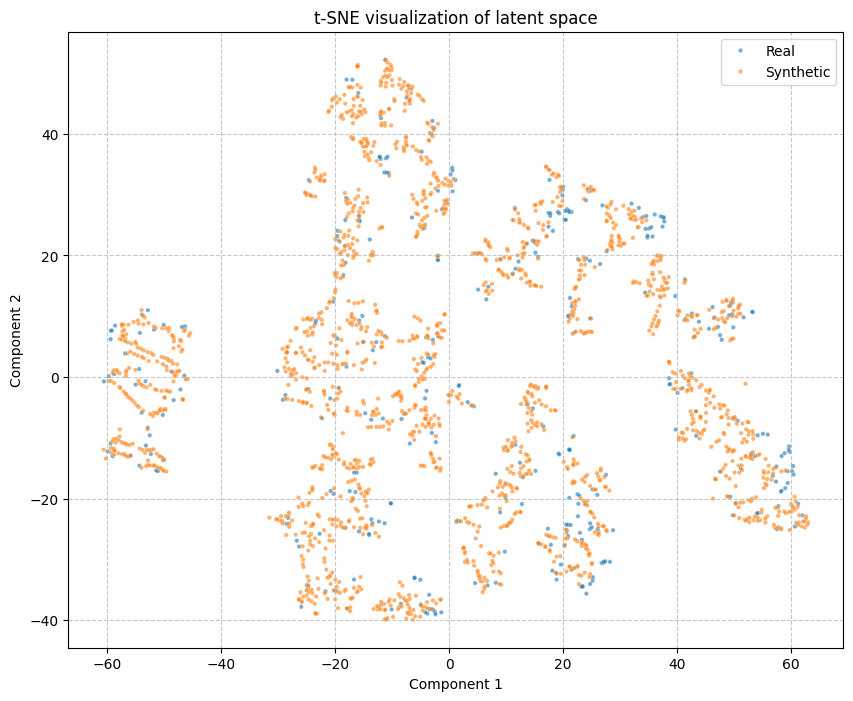

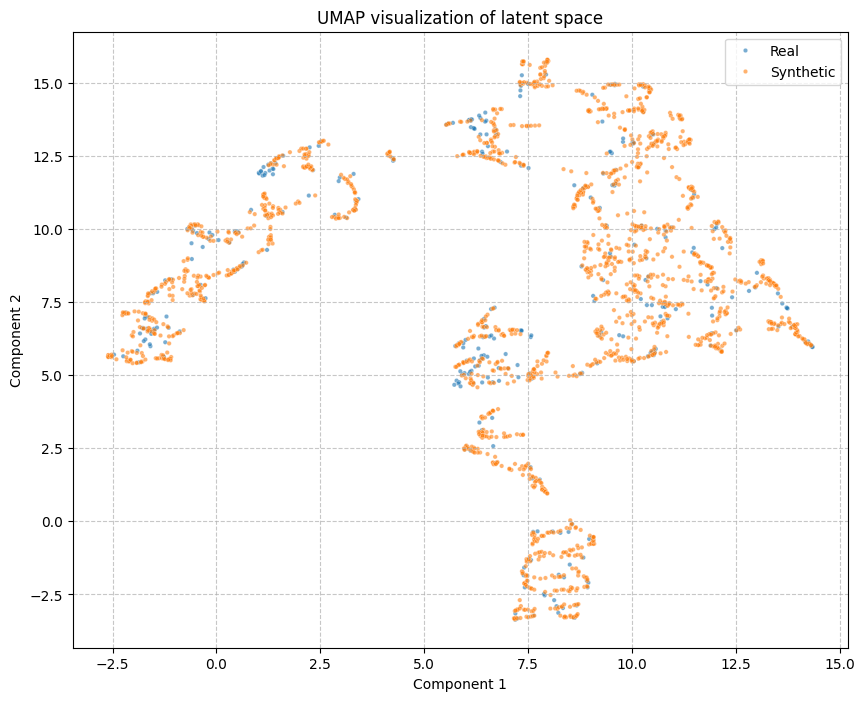

In [ ]:
"""t-SNE/UMAP"""

import seaborn as sns
from sklearn.manifold import TSNE
import umap

if isinstance(real_latents, torch.Tensor):
    real_latents = real_latents.cpu().numpy()
if isinstance(synth_latents, torch.Tensor):
    synth_latents = synth_latents.cpu().numpy()

# 1. Combine Latents and Create Labels
all_latents= np.vstack((real_latents, synth_latents))
labels     = ['Real'] * len(real_latents) + ['Synthetic'] * len(synth_latents)
labels_np  = np.array(labels) # Convert labels to np (easier indexing)

# 2. Apply t-SNE
# n_components: 2 for 2D plot, 3 for 3D plot
# perplexity: controls balance between local and global aspects of data (often 5-50)
# n_iter: number of iterations for optimization
tsne_results = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
print("t-SNE done.")

# 3. Apply UMAP
# n_neighbors: balances local vs. global structure (smaller for local, larger for global)
# min_dist: controls how tightly points are packed together
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(all_latents)
print("UMAP done.")

# 4. Plotting
def plot_latent_space(embedding, labels, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels,
                    palette=['#1f77b4', '#ff7f0e'], s=10, alpha=0.6, legend='full')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_latent_space(tsne_results, labels_np, 't-SNE visualization of latent space')
plot_latent_space(umap_results, labels_np, 'UMAP visualization of latent space')

# # To make 3D plots, set n_components=3
# from mpl_toolkits.mplot3d import Axes3D
# def plot_latent_space_3d(embedding, labels, title):
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     colors = {'Real': '#1f77b4', 'Synthetic': '#ff7f0e'}
#     for label_val in np.unique(labels):
#         idx = (labels == label_val)
#         ax.scatter(embedding[idx, 0], embedding[idx, 1], embedding[idx, 2],
#                    color=colors[label_val], label=label_val, s=10, alpha=0.6)
#     ax.set_title(title)
#     ax.set_xlabel('Component 1')
#     ax.set_ylabel('Component 2')
#     ax.set_zlabel('Component 3')
#     ax.legend()
#     plt.show()
# tsne_results_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
# umap_results_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(all_latents)
# plot_latent_space_3d(tsne_results_3d, labels_np, 't-SNE 3D Visualization of Latent Space')
# plot_latent_space_3d(umap_results_3d, labels_np, 'UMAP 3D Visualization of Latent Space')
